In [3]:
from google.colab import files

uploaded = files.upload()

Saving Forest Dataset.zip to Forest Dataset (2).zip


In [4]:
import os

print(os.listdir())

['.config', 'forestfires.csv', 'Forest Dataset.zip', 'Forest Dataset (1).zip', 'Forest Dataset (2).zip', 'sample_data']


In [5]:
import zipfile

with zipfile.ZipFile("Forest Dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Extracted Successfully")

Extracted Successfully


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import pickle

In [7]:
df = pd.read_csv("forestfires.csv")

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [9]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [10]:
df.shape

(517, 13)

In [11]:
df.isnull().sum()

,0
X,0
Y,0
month,0
day,0
FFMC,0
DMC,0
DC,0
ISI,0
temp,0
RH,0


In [12]:
encoder = LabelEncoder()

df["month"] = encoder.fit_transform(df["month"])

df["day"] = encoder.fit_transform(df["day"])

In [13]:
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


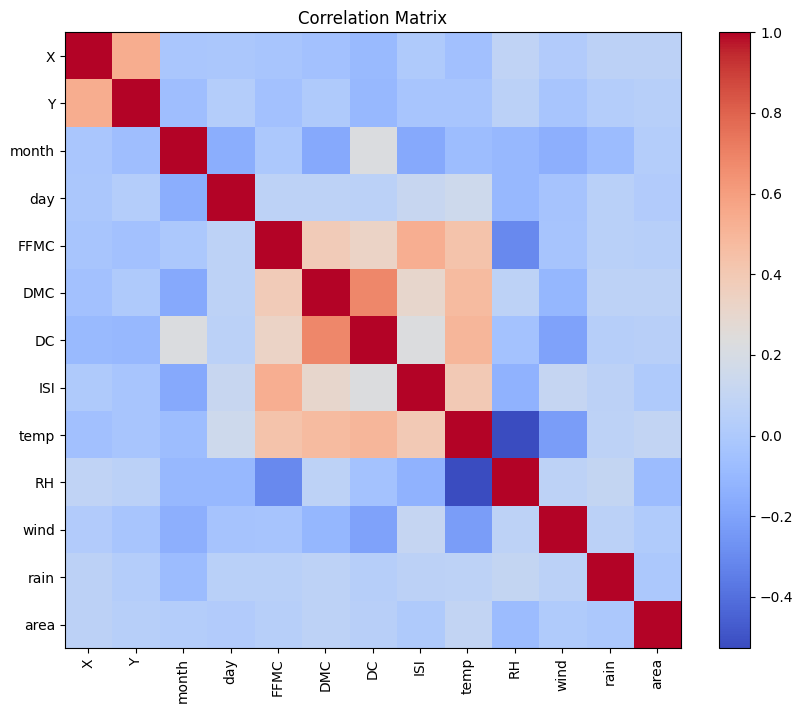

In [14]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [17]:
X = df.drop("area", axis=1)

y = df["area"]

In [18]:
X

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,1,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0
513,2,4,1,3,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0
514,7,4,1,3,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0
515,1,4,1,2,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
X_train

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
329,4,3,11,2,92.2,102.3,751.5,8.4,23.5,27,4.0,0.0
173,4,4,11,1,90.9,126.5,686.5,7.0,17.7,39,2.2,0.0
272,2,5,1,5,92.1,152.6,658.2,14.3,20.2,47,4.0,0.0
497,3,4,1,5,96.1,181.1,671.2,14.3,32.3,27,2.2,0.0
182,5,4,3,3,86.8,15.6,48.3,3.9,12.4,53,2.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
71,4,5,11,0,94.3,85.1,692.3,15.9,17.7,37,3.6,0.0
106,4,5,7,4,91.4,30.7,74.3,7.5,18.2,29,3.1,0.0
270,2,2,1,5,92.1,152.6,658.2,14.3,21.8,56,3.1,0.0
435,2,5,5,2,90.8,84.7,376.6,5.6,23.8,51,1.8,0.0


In [22]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [23]:
prediction = model.predict(X_test)

In [24]:
print("MAE :", mean_absolute_error(y_test, prediction))

print("MSE :", mean_squared_error(y_test, prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

print("R2 Score :", r2_score(y_test, prediction))

MAE : 27.483421698717944
MSE : 12117.879040553536
RMSE : 110.08123836764163
R2 Score : -0.028005054433826393


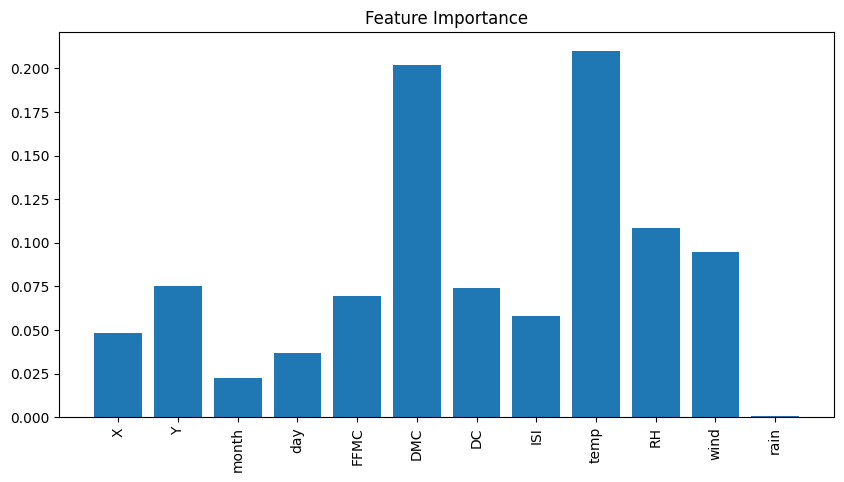

In [25]:
importance = model.feature_importances_

feature = X.columns

plt.figure(figsize=(10,5))

plt.bar(feature, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [26]:
pickle.dump(model, open("forest_fire_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [27]:
loaded_model = pickle.load(open("forest_fire_model.pkl", "rb"))

In [28]:
sample = [[
    7,      # X
    5,      # Y
    7,      # month (encoded)
    2,      # day (encoded)
    86.2,   # FFMC
    26.2,   # DMC
    94.3,   # DC
    5.1,    # ISI
    8.2,    # temp
    51,     # RH
    6.7,    # wind
    0.0     # rain
]]

result = loaded_model.predict(sample)

print("Predicted Burn Area :", result[0])

Predicted Burn Area : 8.22423


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
